<table width="100%">
<tr>
<td width="50%" align="left"><a href="./01_RQ1_population_demand.ipynb">← Previous: RQ1 — Population Demand</a></td>
<td width="50%" align="right"><a href="./03_RQ3_expenditure_resources.ipynb">Next: RQ3 — Expenditure Resources →</a></td>
</tr>
</table>

## **2.0 Healthcare Capacity**

#### This section examines how healthcare capacity has changed across Canadian provinces. Is capacity keeping pace with changes in population and changes demography?

> - #### **Research Question 2: How has healthcare capacity changed across Canadian provinces and territories, and has capacity kept pace with population and demographic demand?**

In [1]:
import pandas as pd
import numpy as np

from sqlalchemy import create_engine
from dotenv import load_dotenv

import os

import matplotlib.pyplot as plt

In [2]:
import pandas as pd
from daytascape_db_core.connection import get_db_engine

In [3]:
DATABASE = "health_system_performance"

engine = get_db_engine(DATABASE)

print("Connected database:", engine.url.database)

Connected database: health_system_performance


In [4]:
query = """
SELECT *
FROM master.analytics_province_year;
"""

df = pd.read_sql(query, engine)

print("Connected successfully to database!")

df.head(10)

Connected successfully to database!


,province_id,province_code,province_name,data_year,population,population_65_plus,population_80_plus,population_85_plus,population_65_share_pct,population_80_share_pct,...,private_health_expenditure_constant_2010_per_capita,provincial_government_health_expenditure_current,provincial_government_health_expenditure_per_capita,provincial_government_health_expenditure_constant_2010,provincial_government_health_expenditure_constant_2010_per_capi,territorial_government_health_expenditure_current,territorial_government_health_expenditure_per_capita,territorial_government_health_expenditure_constant_2010,territorial_government_health_expenditure_constant_2010_per_cap,nurses_total
0,15,PE,Prince Edward Island,2024,179709.0,36849.0,8218.0,3886.0,20.504816,4.572948,...,1914.110532,1.228779e+09,6881.989110,8.254174e+08,4622.892113,NaN,NaN,NaN,NaN,NaN
1,6,AB,Alberta,1975,1808689.0,134156.0,27442.0,12282.0,7.417306,1.517232,...,663.549287,6.949125e+08,384.207843,3.428803e+09,1895.739423,NaN,NaN,NaN,NaN,NaN
2,7,BC,British Columbia,1975,2499564.0,236960.0,51071.0,23239.0,9.480053,2.043196,...,679.794364,9.281825e+08,371.337761,4.379023e+09,1751.914626,NaN,NaN,NaN,NaN,NaN
3,7,BC,British Columbia,2022,5358845.0,1054174.0,250939.0,124925.0,19.671664,4.682707,...,2273.051979,3.010337e+10,5618.936230,2.317900e+10,4326.469070,NaN,NaN,NaN,NaN,108708.0
4,9,NB,New Brunswick,2021,790802.0,178652.0,39837.0,19193.0,22.591243,5.037544,...,2191.698134,3.945472e+09,4989.203072,3.151362e+09,3985.020465,NaN,NaN,NaN,NaN,NaN
5,5,CA,Canada,1975,23143275.0,1957075.0,377982.0,160362.0,8.456344,1.633226,...,568.363206,8.709289e+09,376.320519,4.111742e+10,1776.646681,NaN,NaN,NaN,NaN,NaN
6,8,MB,Manitoba,1975,1024975.0,104215.0,22287.0,9920.0,10.167565,2.174394,...,494.535967,3.766992e+08,367.520427,1.852127e+09,1806.997401,NaN,NaN,NaN,NaN,NaN
7,14,ON,Ontario,1980,8746013.0,850356.0,165961.0,70416.0,9.722785,1.897562,...,776.538159,5.164564e+09,590.505011,1.629120e+10,1862.700006,NaN,NaN,NaN,NaN,NaN
8,16,QC,Quebec,2020,8551095.0,1673371.0,401828.0,204785.0,19.569084,4.699141,...,1755.558556,4.704125e+10,5501.196296,3.642464e+10,4259.646558,NaN,NaN,NaN,NaN,NaN
9,14,ON,Ontario,2016,13876500.0,2260652.0,593482.0,302656.0,16.291226,4.276885,...,2000.807682,5.655294e+10,4075.446981,5.104966e+10,3678.856840,NaN,NaN,NaN,NaN,NaN


In [5]:
query = """
SELECT
    Province_id,
    province_code,
    province_name,
    data_year,
    population,
    population_65_plus,
    population_80_plus,
    population_85_plus,
    population_65_share_pct,
    population_80_share_pct,
    population_85_share_pct,
    hospital_beds_total,
    current_hospital_beds_total,
    physicians_total,
    registered_nurses,
    licensed_practical_nurses,
    nurse_practitioners,
    registered_psychiatric_nurses,
    icu_beds,
    long_term_care_beds,
    mental_health_addictions_beds,
    obstetrics_beds,
    other_acute_care_beds,
    pediatrics_beds,
    rated_capacity_beds,
    rehabilitation_beds
FROM master.analytics_province_year
WHERE province_code NOT IN ('CA', 'NT', 'YT', 'NU')
ORDER BY province_name, data_year;
"""

df_healthcare_capacity = pd.read_sql(query, engine)

In [6]:
df_healthcare_capacity

,province_id,province_code,province_name,data_year,population,population_65_plus,population_80_plus,population_85_plus,population_65_share_pct,population_80_share_pct,...,nurse_practitioners,registered_psychiatric_nurses,icu_beds,long_term_care_beds,mental_health_addictions_beds,obstetrics_beds,other_acute_care_beds,pediatrics_beds,rated_capacity_beds,rehabilitation_beds
0,6,AB,Alberta,1971,1665717.0,120453.0,25438.0,10431.0,7.231300,1.527150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6,AB,Alberta,1972,1694090.0,123588.0,26188.0,10894.0,7.295244,1.545845,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6,AB,Alberta,1973,1725327.0,126985.0,26669.0,11424.0,7.360054,1.545736,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6,AB,Alberta,1974,1754621.0,130045.0,27048.0,11973.0,7.411572,1.541529,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6,AB,Alberta,1975,1808689.0,134156.0,27442.0,12282.0,7.417306,1.517232,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,17,SK,Saskatchewan,2021,1167711.0,198565.0,50771.0,27399.0,17.004636,4.347908,...,240.0,713.0,66.0,22.0,401.0,116.0,1334.0,78.0,2061.0,80.0
546,17,SK,Saskatchewan,2022,1178796.0,204647.0,50862.0,26970.0,17.360680,4.314741,...,263.0,679.0,77.0,0.0,523.0,187.0,2390.0,69.0,144.0,73.0
547,17,SK,Saskatchewan,2023,1210257.0,211510.0,51537.0,26972.0,17.476453,4.258352,...,254.0,692.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
548,17,SK,Saskatchewan,2024,1247868.0,218531.0,52274.0,27014.0,17.512349,4.189065,...,267.0,702.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df_healthcare_capacity["bed_change"] = (
    df_healthcare_capacity
    .sort_values(["province_code", "data_year"])
    .groupby("province_code")["hospital_beds_total"].diff()

)

In [8]:
df_healthcare_capacity[
    [
        "province_code",
        "province_name",
        "data_year",
        "hospital_beds_total",
        "bed_change"
    ]
].head(10)

,province_code,province_name,data_year,hospital_beds_total,bed_change
0,AB,Alberta,1971,NaN,NaN
1,AB,Alberta,1972,NaN,NaN
2,AB,Alberta,1973,NaN,NaN
3,AB,Alberta,1974,NaN,NaN
4,AB,Alberta,1975,NaN,NaN
5,AB,Alberta,1976,NaN,NaN
6,AB,Alberta,1977,NaN,NaN
7,AB,Alberta,1978,NaN,NaN
8,AB,Alberta,1979,NaN,NaN
9,AB,Alberta,1980,NaN,NaN


In [9]:
df_healthcare_capacity[
    df_healthcare_capacity["hospital_beds_total"].notna()
][
    [
        "province_code",
        "province_name",
        "data_year",
        "hospital_beds_total",
        "bed_change"
    ]
].head(10)

,province_code,province_name,data_year,hospital_beds_total,bed_change
38,AB,Alberta,2009,10700.0,NaN
39,AB,Alberta,2010,13311.0,2611.0
40,AB,Alberta,2011,11015.0,-2296.0
41,AB,Alberta,2012,11048.0,33.0
42,AB,Alberta,2013,11146.0,98.0
43,AB,Alberta,2014,11053.0,-93.0
44,AB,Alberta,2015,11171.0,118.0
45,AB,Alberta,2016,11021.0,-150.0
46,AB,Alberta,2017,10859.0,-162.0
47,AB,Alberta,2018,10898.0,39.0


In [10]:
df_healthcare_capacity["bed_growth_pct"] = (
    df_healthcare_capacity
    .sort_values(["province_code", "data_year"])
    .groupby("province_code")["hospital_beds_total"]
    .pct_change()
    * 100
)

df_healthcare_capacity

,province_id,province_code,province_name,data_year,population,population_65_plus,population_80_plus,population_85_plus,population_65_share_pct,population_80_share_pct,...,icu_beds,long_term_care_beds,mental_health_addictions_beds,obstetrics_beds,other_acute_care_beds,pediatrics_beds,rated_capacity_beds,rehabilitation_beds,bed_change,bed_growth_pct
0,6,AB,Alberta,1971,1665717.0,120453.0,25438.0,10431.0,7.231300,1.527150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6,AB,Alberta,1972,1694090.0,123588.0,26188.0,10894.0,7.295244,1.545845,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6,AB,Alberta,1973,1725327.0,126985.0,26669.0,11424.0,7.360054,1.545736,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6,AB,Alberta,1974,1754621.0,130045.0,27048.0,11973.0,7.411572,1.541529,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6,AB,Alberta,1975,1808689.0,134156.0,27442.0,12282.0,7.417306,1.517232,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,17,SK,Saskatchewan,2021,1167711.0,198565.0,50771.0,27399.0,17.004636,4.347908,...,66.0,22.0,401.0,116.0,1334.0,78.0,2061.0,80.0,667.0,19.106273
546,17,SK,Saskatchewan,2022,1178796.0,204647.0,50862.0,26970.0,17.360680,4.314741,...,77.0,0.0,523.0,187.0,2390.0,69.0,144.0,73.0,-695.0,-16.714767
547,17,SK,Saskatchewan,2023,1210257.0,211510.0,51537.0,26972.0,17.476453,4.258352,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
548,17,SK,Saskatchewan,2024,1247868.0,218531.0,52274.0,27014.0,17.512349,4.189065,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df_bed_trend = (
    df_healthcare_capacity[
        df_healthcare_capacity["hospital_beds_total"].notna()
    ]
    .groupby("data_year")["bed_change"]
    .agg(
        total_bed_change="sum",
        average_bed_change="mean"
    )
    .reset_index()
)

df_bed_trend

,data_year,total_bed_change,average_bed_change
0,2009,0.0,NaN
1,2010,2929.0,325.444444
2,2011,-3063.0,-340.333333
3,2012,-330.0,-33.000000
4,2013,-595.0,-59.500000
5,2014,-896.0,-89.600000
6,2015,-162.0,-16.200000
7,2016,-258.0,-25.800000
8,2017,176.0,17.600000
9,2018,1394.0,139.400000


### **2.1 - Bed Capacity change across Provinces (2009-2022)**

In [12]:
df_bed_capacity_change = (df_healthcare_capacity[
  df_healthcare_capacity["hospital_beds_total"].notna()
].groupby(
    ["province_code", "province_name"]
).agg(
    start_year=("data_year", "min"),
    end_year=("data_year", "max"),
    start_beds=("hospital_beds_total", "first"),
    end_beds=("hospital_beds_total", "last")
).reset_index()
)

In [13]:
df_bed_capacity_change["bed_change_absolute"] = (
    df_bed_capacity_change["end_beds"] - df_bed_capacity_change["start_beds"]
)

In [14]:
df_bed_capacity_change.sort_values(
    "bed_change_absolute",
    ascending=False
)

,province_code,province_name,start_year,end_year,start_beds,end_beds,bed_change_absolute
6,ON,Ontario,2009,2022,31532.0,34781.0,3249.0
0,AB,Alberta,2009,2022,10700.0,10859.0,159.0
5,NS,Nova Scotia,2009,2022,3155.0,3241.0,86.0
2,MB,Manitoba,2009,2022,4141.0,4178.0,37.0
4,NL,Newfoundland and Labrador,2009,2022,2148.0,2184.0,36.0
8,QC,Quebec,2011,2022,19815.0,19834.0,19.0
9,SK,Saskatchewan,2009,2022,3554.0,3463.0,-91.0
7,PE,Prince Edward Island,2009,2022,596.0,481.0,-115.0
3,NB,New Brunswick,2009,2022,2789.0,2552.0,-237.0
1,BC,British Columbia,2009,2022,15250.0,12459.0,-2791.0


### **2.2 - Changes in Bed Capacity Across Provinces**

In [15]:
df_bed_capacity_change["bed_change_pct"] = (
    df_bed_capacity_change["bed_change_absolute"]
    / df_bed_capacity_change["start_beds"]
) * 100

In [16]:
df_bed_capacity_change.sort_values("bed_change_pct", ascending=False)

,province_code,province_name,start_year,end_year,start_beds,end_beds,bed_change_absolute,bed_change_pct
6,ON,Ontario,2009,2022,31532.0,34781.0,3249.0,10.303818
5,NS,Nova Scotia,2009,2022,3155.0,3241.0,86.0,2.725832
4,NL,Newfoundland and Labrador,2009,2022,2148.0,2184.0,36.0,1.675978
0,AB,Alberta,2009,2022,10700.0,10859.0,159.0,1.485981
2,MB,Manitoba,2009,2022,4141.0,4178.0,37.0,0.893504
8,QC,Quebec,2011,2022,19815.0,19834.0,19.0,0.095887
9,SK,Saskatchewan,2009,2022,3554.0,3463.0,-91.0,-2.560495
3,NB,New Brunswick,2009,2022,2789.0,2552.0,-237.0,-8.497669
1,BC,British Columbia,2009,2022,15250.0,12459.0,-2791.0,-18.301639
7,PE,Prince Edward Island,2009,2022,596.0,481.0,-115.0,-19.295302


> ##### **Insights:**
> - ##### Between 2009 and 2022, some provinces expanded staffed-and-operational capacity, while others contracted. Ontario increased capacity substantially, whereas British Columbia and Prince Edward Island experienced notable endpoint declines. Alberta was broadly stable despite considerable year-to-year fluctuations.

### **2.3 - BSIO per population**

In [17]:
df_healthcare_capacity["beds_per_100k"] = (
    df_healthcare_capacity["hospital_beds_total"]
    / df_healthcare_capacity["population"]
) * 100000

In [18]:
df_healthcare_capacity[
    df_healthcare_capacity["beds_per_100k"].notna()
].sort_values(
    ["province_code", "data_year"]
).head()

,province_id,province_code,province_name,data_year,population,population_65_plus,population_80_plus,population_85_plus,population_65_share_pct,population_80_share_pct,...,long_term_care_beds,mental_health_addictions_beds,obstetrics_beds,other_acute_care_beds,pediatrics_beds,rated_capacity_beds,rehabilitation_beds,bed_change,bed_growth_pct,beds_per_100k
38,6,AB,Alberta,2009,3679010.0,383007.0,102001.0,48005.0,10.410600,2.772512,...,2713.0,1356.0,513.0,5255.0,307.0,NaN,224.0,NaN,NaN,290.839112
39,6,AB,Alberta,2010,3732104.0,393689.0,105639.0,49703.0,10.548715,2.830548,...,5247.0,1232.0,328.0,5281.0,324.0,269.0,225.0,2611.0,24.401869,356.662087
40,6,AB,Alberta,2011,3787705.0,407025.0,109383.0,51769.0,10.745953,2.887844,...,2530.0,1418.0,416.0,5688.0,318.0,NaN,240.0,-2296.0,-17.248892,290.809342
41,6,AB,Alberta,2012,3871947.0,426052.0,112890.0,54013.0,11.003560,2.915587,...,2482.0,1349.0,415.0,5770.0,319.0,NaN,363.0,33.0,0.299591,285.334484
42,6,AB,Alberta,2013,3978532.0,445947.0,116103.0,56217.0,11.208833,2.918237,...,2449.0,1359.0,425.0,5763.0,311.0,8.0,463.0,98.0,0.887038,280.153584


### **2.3.1 - Relative Capacity Change for Each Province**

In [19]:
df_bed_capacity_per_100k_change = (
    df_healthcare_capacity[
    df_healthcare_capacity["beds_per_100k"].notna()
    ]
    .groupby(["province_code", "province_name"])
    .agg(
        start_year=("data_year", "min"),
        end_year=("data_year", "max"),
        start_beds_per_100k=("beds_per_100k", "first"),
        end_beds_per_100k=("beds_per_100k", "last")
    )
    .reset_index()
)

df_bed_capacity_per_100k_change

,province_code,province_name,start_year,end_year,start_beds_per_100k,end_beds_per_100k
0,AB,Alberta,2009,2022,290.839112,240.630341
1,BC,British Columbia,2009,2022,345.764767,232.494129
2,MB,Manitoba,2009,2022,342.640591,295.578770
3,NB,New Brunswick,2009,2022,371.888484,315.502263
4,NL,Newfoundland and Labrador,2009,2022,415.682131,411.100465
5,NS,Nova Scotia,2009,2022,336.258588,316.493398
6,ON,Ontario,2009,2022,242.573607,229.489155
7,PE,Prince Edward Island,2009,2022,426.100820,287.679426
8,QC,Quebec,2011,2022,247.540956,228.766836
9,SK,Saskatchewan,2009,2022,343.450996,293.774326


In [20]:
df_bed_capacity_per_100k_change["beds_per_100k_change_pct"] = (
    (
        df_bed_capacity_per_100k_change["end_beds_per_100k"]
        - df_bed_capacity_per_100k_change["start_beds_per_100k"]
    )/ df_bed_capacity_per_100k_change["start_beds_per_100k"]
) * 100

In [21]:
df_bed_capacity_per_100k_change[
    [
        "province_code",
        "province_name",
        "start_beds_per_100k",
        "end_beds_per_100k",
        "beds_per_100k_change_pct"
    ]
].sort_values("beds_per_100k_change_pct")

,province_code,province_name,start_beds_per_100k,end_beds_per_100k,beds_per_100k_change_pct
1,BC,British Columbia,345.764767,232.494129,-32.759451
7,PE,Prince Edward Island,426.100820,287.679426,-32.485597
0,AB,Alberta,290.839112,240.630341,-17.263418
3,NB,New Brunswick,371.888484,315.502263,-15.162132
9,SK,Saskatchewan,343.450996,293.774326,-14.463976
2,MB,Manitoba,342.640591,295.578770,-13.735040
8,QC,Quebec,247.540956,228.766836,-7.584248
5,NS,Nova Scotia,336.258588,316.493398,-5.877973
6,ON,Ontario,242.573607,229.489155,-5.394013
4,NL,Newfoundland and Labrador,415.682131,411.100465,-1.102204


> ##### **Insights:** 
> - ##### Between the 2009 and 2022, all 10 provinces experienced a decline in staffed-and-operational hospital beds per 100,000 population. Decline ranges from -1.1 percent to -32.8 percent.

### **2.4 - Provincial Bed Capacity Relative to Population (2009-2022)**

In [22]:
df_bed_capacity_change

,province_code,province_name,start_year,end_year,start_beds,end_beds,bed_change_absolute,bed_change_pct
0,AB,Alberta,2009,2022,10700.0,10859.0,159.0,1.485981
1,BC,British Columbia,2009,2022,15250.0,12459.0,-2791.0,-18.301639
2,MB,Manitoba,2009,2022,4141.0,4178.0,37.0,0.893504
3,NB,New Brunswick,2009,2022,2789.0,2552.0,-237.0,-8.497669
4,NL,Newfoundland and Labrador,2009,2022,2148.0,2184.0,36.0,1.675978
5,NS,Nova Scotia,2009,2022,3155.0,3241.0,86.0,2.725832
6,ON,Ontario,2009,2022,31532.0,34781.0,3249.0,10.303818
7,PE,Prince Edward Island,2009,2022,596.0,481.0,-115.0,-19.295302
8,QC,Quebec,2011,2022,19815.0,19834.0,19.0,0.095887
9,SK,Saskatchewan,2009,2022,3554.0,3463.0,-91.0,-2.560495


In [23]:
#### Recalled from Notebook 1 (RQ1 - Population)

query = """
    SELECT
    province_id,
    province_code,
    province_name,
    data_year,
    population,
    population_65_plus,
    population_80_plus,
    population_85_plus,
    population_65_share_pct,
    population_80_share_pct,
    population_85_share_pct
FROM master.analytics_province_year
WHERE province_code NOT IN ('CA', 'NT', 'YT', 'NU')
ORDER BY province_name, data_year;
"""

df_population_demand = pd.read_sql(query, engine)

df_population_demand
df_population_demand["population_growth_pct"] = (
    df_population_demand
    .groupby('province_code')["population"]
    .pct_change() * 100
)

df_population_demand
df_population_demand[
    [
        "province_name",
        "province_code",
        "population",
        "population_growth_pct"
    ]
    
].head()
df_population_demand["population_growth_pct"].describe()
df_population_change = (
    df_population_demand
    .sort_values(["province_code", "data_year"])
    .groupby(["province_code", "province_name"])
    .agg(
        start_year=("data_year", "min"),
        end_year=("data_year", "max"),
        start_population=("population", "first"),
        end_population=("population", "last")
        
    )
    .reset_index()
)
df_population_change
df_population_change["absolute_change"] =(
    df_population_change["end_population"] - 
    df_population_change["start_population"]
)
df_population_change["population_change_pct"] = (
    df_population_change["absolute_change"]
    / df_population_change["start_population"]
) * 100

df_population_change

,province_code,province_name,start_year,end_year,start_population,end_population,absolute_change,population_change_pct
0,AB,Alberta,1971,2025,1665717.0,5029346.0,3363629.0,201.932801
1,BC,British Columbia,1971,2025,2240470.0,5697536.0,3457066.0,154.300928
2,MB,Manitoba,1971,2025,998876.0,1509702.0,510826.0,51.140081
3,NB,New Brunswick,1971,2025,642471.0,869682.0,227211.0,35.365176
4,NL,Newfoundland and Labrador,1971,2025,530854.0,549911.0,19057.0,3.589876
5,NS,Nova Scotia,1971,2025,797294.0,1093245.0,295951.0,37.119431
6,ON,Ontario,1971,2025,7849027.0,16258260.0,8409233.0,107.137267
7,PE,Prince Edward Island,1971,2025,112591.0,182657.0,70066.0,62.230551
8,QC,Quebec,1971,2025,6137305.0,9058297.0,2920992.0,47.594050
9,SK,Saskatchewan,1971,2025,932038.0,1266959.0,334921.0,35.934264


In [24]:
df_population_change[
    [
        "province_code",
        "province_name",
        "start_year",
        "end_year"
    ]
]

,province_code,province_name,start_year,end_year
0,AB,Alberta,1971,2025
1,BC,British Columbia,1971,2025
2,MB,Manitoba,1971,2025
3,NB,New Brunswick,1971,2025
4,NL,Newfoundland and Labrador,1971,2025
5,NS,Nova Scotia,1971,2025
6,ON,Ontario,1971,2025
7,PE,Prince Edward Island,1971,2025
8,QC,Quebec,1971,2025
9,SK,Saskatchewan,1971,2025


In [25]:
df_bed_capacity_change[
    [
        "province_code",
        "province_name",
        "start_year",
        "end_year"
    ]
]

,province_code,province_name,start_year,end_year
0,AB,Alberta,2009,2022
1,BC,British Columbia,2009,2022
2,MB,Manitoba,2009,2022
3,NB,New Brunswick,2009,2022
4,NL,Newfoundland and Labrador,2009,2022
5,NS,Nova Scotia,2009,2022
6,ON,Ontario,2009,2022
7,PE,Prince Edward Island,2009,2022
8,QC,Quebec,2011,2022
9,SK,Saskatchewan,2009,2022


In [26]:
df_population_capacity = df_healthcare_capacity[
    (df_healthcare_capacity["province_code"] != "CA") &
    (df_healthcare_capacity["data_year"].isin([2009, 2022]))
][
    ["province_code", "province_name", "data_year", "population"]
]

df_population_capacity.head(10)

,province_code,province_name,data_year,population
38,AB,Alberta,2009,3679010.0
51,AB,Alberta,2022,4512731.0
93,BC,British Columbia,2009,4410513.0
106,BC,British Columbia,2022,5358845.0
148,MB,Manitoba,2009,1208555.0
161,MB,Manitoba,2022,1413498.0
203,NB,New Brunswick,2009,749956.0
216,NB,New Brunswick,2022,808869.0
258,NL,Newfoundland and Labrador,2009,516741.0
271,NL,Newfoundland and Labrador,2022,531257.0


In [27]:
df_population_capacity = (
    df_population_capacity
    .pivot(
        index=["province_code", "province_name"],
        columns="data_year",
        values="population"
    )
    .reset_index()
)

In [28]:
df_population_capacity

data_year,province_code,province_name,2009,2022
0,AB,Alberta,3679010.0,4512731.0
1,BC,British Columbia,4410513.0,5358845.0
2,MB,Manitoba,1208555.0,1413498.0
3,NB,New Brunswick,749956.0,808869.0
4,NL,Newfoundland and Labrador,516741.0,531257.0
5,NS,Nova Scotia,938266.0,1024034.0
6,ON,Ontario,12998941.0,15155836.0
7,PE,Prince Edward Island,139873.0,167200.0
8,QC,Quebec,7843915.0,8669963.0
9,SK,Saskatchewan,1034791.0,1178796.0


In [29]:
df_population_capacity["population_change_pct"] = (
    (df_population_capacity[2022] - df_population_capacity[2009])
    / df_population_capacity[2009]
) * 100

In [30]:
df_population_capacity

data_year,province_code,province_name,2009,2022,population_change_pct
0,AB,Alberta,3679010.0,4512731.0,22.661558
1,BC,British Columbia,4410513.0,5358845.0,21.501626
2,MB,Manitoba,1208555.0,1413498.0,16.957689
3,NB,New Brunswick,749956.0,808869.0,7.855528
4,NL,Newfoundland and Labrador,516741.0,531257.0,2.809144
5,NS,Nova Scotia,938266.0,1024034.0,9.141118
6,ON,Ontario,12998941.0,15155836.0,16.592852
7,PE,Prince Edward Island,139873.0,167200.0,19.537009
8,QC,Quebec,7843915.0,8669963.0,10.531068
9,SK,Saskatchewan,1034791.0,1178796.0,13.916337


In [31]:
df_capacity_vs_population = df_bed_capacity_change[
    
        ["province_code", "province_name", "start_year",
        "end_year", "start_beds", "end_beds", "bed_change_pct"]
].merge(
    df_population_capacity[
            ["province_code", "population_change_pct"]
        ],
        on="province_code",
        how="inner"
)
df_capacity_vs_population

,province_code,province_name,start_year,end_year,start_beds,end_beds,bed_change_pct,population_change_pct
0,AB,Alberta,2009,2022,10700.0,10859.0,1.485981,22.661558
1,BC,British Columbia,2009,2022,15250.0,12459.0,-18.301639,21.501626
2,MB,Manitoba,2009,2022,4141.0,4178.0,0.893504,16.957689
3,NB,New Brunswick,2009,2022,2789.0,2552.0,-8.497669,7.855528
4,NL,Newfoundland and Labrador,2009,2022,2148.0,2184.0,1.675978,2.809144
5,NS,Nova Scotia,2009,2022,3155.0,3241.0,2.725832,9.141118
6,ON,Ontario,2009,2022,31532.0,34781.0,10.303818,16.592852
7,PE,Prince Edward Island,2009,2022,596.0,481.0,-19.295302,19.537009
8,QC,Quebec,2011,2022,19815.0,19834.0,0.095887,10.531068
9,SK,Saskatchewan,2009,2022,3554.0,3463.0,-2.560495,13.916337


In [32]:
df_capacity_vs_population["capacity_population_gap_pp"] = (
    df_capacity_vs_population["bed_change_pct"] - df_capacity_vs_population["population_change_pct"]
)

In [33]:
df_capacity_vs_population

,province_code,province_name,start_year,end_year,start_beds,end_beds,bed_change_pct,population_change_pct,capacity_population_gap_pp
0,AB,Alberta,2009,2022,10700.0,10859.0,1.485981,22.661558,-21.175577
1,BC,British Columbia,2009,2022,15250.0,12459.0,-18.301639,21.501626,-39.803265
2,MB,Manitoba,2009,2022,4141.0,4178.0,0.893504,16.957689,-16.064185
3,NB,New Brunswick,2009,2022,2789.0,2552.0,-8.497669,7.855528,-16.353197
4,NL,Newfoundland and Labrador,2009,2022,2148.0,2184.0,1.675978,2.809144,-1.133167
5,NS,Nova Scotia,2009,2022,3155.0,3241.0,2.725832,9.141118,-6.415286
6,ON,Ontario,2009,2022,31532.0,34781.0,10.303818,16.592852,-6.289033
7,PE,Prince Edward Island,2009,2022,596.0,481.0,-19.295302,19.537009,-38.832311
8,QC,Quebec,2011,2022,19815.0,19834.0,0.095887,10.531068,-10.435181
9,SK,Saskatchewan,2009,2022,3554.0,3463.0,-2.560495,13.916337,-16.476832


In [34]:
df_capacity_vs_population[
    [
        "province_code",
        "province_name",
        "bed_change_pct",
        "population_change_pct",
        "capacity_population_gap_pp"
    ]
].sort_values("capacity_population_gap_pp", ascending=True)

,province_code,province_name,bed_change_pct,population_change_pct,capacity_population_gap_pp
1,BC,British Columbia,-18.301639,21.501626,-39.803265
7,PE,Prince Edward Island,-19.295302,19.537009,-38.832311
0,AB,Alberta,1.485981,22.661558,-21.175577
9,SK,Saskatchewan,-2.560495,13.916337,-16.476832
3,NB,New Brunswick,-8.497669,7.855528,-16.353197
2,MB,Manitoba,0.893504,16.957689,-16.064185
8,QC,Quebec,0.095887,10.531068,-10.435181
5,NS,Nova Scotia,2.725832,9.141118,-6.415286
6,ON,Ontario,10.303818,16.592852,-6.289033
4,NL,Newfoundland and Labrador,1.675978,2.809144,-1.133167


> ##### **Insights:** 
> - ##### Between 2009 and 2022, population growth exceeded the growth of staffed and operating hospital beds in all provinces. British Columbia, Prince Edward Island, Alberta, Saskatchewan, New Brunswick and Manitoba experienced the largest capacity-population divergence. This suggests that population increased substantially faster than hospital bed capacity. Newfoundland and Labrador showed the closest alignment between population at 1.1 percentage points.
> - ##### Overall, the findings suggests that hospital bed capacity in general did not expand at the same rate as population growth during the priod. This indicates increasing poulation pressure relative to available hopsital capacity. 
> - ##### This represents a descriptive capacity-demand divergence rather than evidence that population growth caused capacity constraints.

#### **2.4.1 - Bed Capacity Relative to the Ageing Poulation**

In [35]:
df_population_demand

,province_id,province_code,province_name,data_year,population,population_65_plus,population_80_plus,population_85_plus,population_65_share_pct,population_80_share_pct,population_85_share_pct,population_growth_pct
0,6,AB,Alberta,1971,1665717.0,120453.0,25438.0,10431.0,7.231300,1.527150,0.626217,NaN
1,6,AB,Alberta,1972,1694090.0,123588.0,26188.0,10894.0,7.295244,1.545845,0.643059,1.703351
2,6,AB,Alberta,1973,1725327.0,126985.0,26669.0,11424.0,7.360054,1.545736,0.662135,1.843881
3,6,AB,Alberta,1974,1754621.0,130045.0,27048.0,11973.0,7.411572,1.541529,0.682370,1.697881
4,6,AB,Alberta,1975,1808689.0,134156.0,27442.0,12282.0,7.417306,1.517232,0.679055,3.081463
...,...,...,...,...,...,...,...,...,...,...,...,...
545,17,SK,Saskatchewan,2021,1167711.0,198565.0,50771.0,27399.0,17.004636,4.347908,2.346385,0.027840
546,17,SK,Saskatchewan,2022,1178796.0,204647.0,50862.0,26970.0,17.360680,4.314741,2.287928,0.949293
547,17,SK,Saskatchewan,2023,1210257.0,211510.0,51537.0,26972.0,17.476453,4.258352,2.228618,2.668910
548,17,SK,Saskatchewan,2024,1247868.0,218531.0,52274.0,27014.0,17.512349,4.189065,2.164812,3.107687


In [36]:
ageing_growth = (
    df_healthcare_capacity[
        (df_healthcare_capacity["province_code"] != "CA") &
        (df_healthcare_capacity["data_year"].isin([2009, 2022]))
    ]
    .pivot(
        index=["province_code", "province_name"],
        columns="data_year",
        values="population_65_plus"
    )
)

In [37]:
ageing_growth

,data_year,2009,2022
province_code,province_name,,
AB,Alberta,383007.0,668205.0
BC,British Columbia,648778.0,1054174.0
MB,Manitoba,167234.0,236133.0
NB,New Brunswick,115845.0,185107.0
NL,Newfoundland and Labrador,75784.0,126975.0
NS,Nova Scotia,146601.0,225308.0
ON,Ontario,1782737.0,2763435.0
PE,Prince Edward Island,21404.0,34523.0
QC,Quebec,1169954.0,1787639.0


In [38]:
ageing_growth["population_65_growth_pct"] = (
    (ageing_growth[2022] - ageing_growth[2009])
    / ageing_growth[2009]
) * 100

In [39]:
ageing_growth = ageing_growth[
    ["population_65_growth_pct"]
].reset_index()

In [40]:
ageing_growth

data_year,province_code,province_name,population_65_growth_pct
0,AB,Alberta,74.462869
1,BC,British Columbia,62.486089
2,MB,Manitoba,41.199158
3,NB,New Brunswick,59.788511
4,NL,Newfoundland and Labrador,67.548559
5,NS,Nova Scotia,53.687901
6,ON,Ontario,55.010806
7,PE,Prince Edward Island,61.292282
8,QC,Quebec,52.795665
9,SK,Saskatchewan,35.296645


In [41]:
df_capacity_vs_population = df_capacity_vs_population.merge(
    ageing_growth,
    on=["province_code", "province_name"],
    how="left"
)

In [42]:
df_capacity_vs_population

,province_code,province_name,start_year,end_year,start_beds,end_beds,bed_change_pct,population_change_pct,capacity_population_gap_pp,population_65_growth_pct
0,AB,Alberta,2009,2022,10700.0,10859.0,1.485981,22.661558,-21.175577,74.462869
1,BC,British Columbia,2009,2022,15250.0,12459.0,-18.301639,21.501626,-39.803265,62.486089
2,MB,Manitoba,2009,2022,4141.0,4178.0,0.893504,16.957689,-16.064185,41.199158
3,NB,New Brunswick,2009,2022,2789.0,2552.0,-8.497669,7.855528,-16.353197,59.788511
4,NL,Newfoundland and Labrador,2009,2022,2148.0,2184.0,1.675978,2.809144,-1.133167,67.548559
5,NS,Nova Scotia,2009,2022,3155.0,3241.0,2.725832,9.141118,-6.415286,53.687901
6,ON,Ontario,2009,2022,31532.0,34781.0,10.303818,16.592852,-6.289033,55.010806
7,PE,Prince Edward Island,2009,2022,596.0,481.0,-19.295302,19.537009,-38.832311,61.292282
8,QC,Quebec,2011,2022,19815.0,19834.0,0.095887,10.531068,-10.435181,52.795665
9,SK,Saskatchewan,2009,2022,3554.0,3463.0,-2.560495,13.916337,-16.476832,35.296645


In [43]:
df_capacity_vs_population["capacity_ageing_gap_pp"] = (
    df_capacity_vs_population["bed_change_pct"]
    - df_capacity_vs_population["population_65_growth_pct"]
)

In [44]:
df_capacity_vs_population

,province_code,province_name,start_year,end_year,start_beds,end_beds,bed_change_pct,population_change_pct,capacity_population_gap_pp,population_65_growth_pct,capacity_ageing_gap_pp
0,AB,Alberta,2009,2022,10700.0,10859.0,1.485981,22.661558,-21.175577,74.462869,-72.976888
1,BC,British Columbia,2009,2022,15250.0,12459.0,-18.301639,21.501626,-39.803265,62.486089,-80.787729
2,MB,Manitoba,2009,2022,4141.0,4178.0,0.893504,16.957689,-16.064185,41.199158,-40.305654
3,NB,New Brunswick,2009,2022,2789.0,2552.0,-8.497669,7.855528,-16.353197,59.788511,-68.286180
4,NL,Newfoundland and Labrador,2009,2022,2148.0,2184.0,1.675978,2.809144,-1.133167,67.548559,-65.872581
5,NS,Nova Scotia,2009,2022,3155.0,3241.0,2.725832,9.141118,-6.415286,53.687901,-50.962069
6,ON,Ontario,2009,2022,31532.0,34781.0,10.303818,16.592852,-6.289033,55.010806,-44.706988
7,PE,Prince Edward Island,2009,2022,596.0,481.0,-19.295302,19.537009,-38.832311,61.292282,-80.587584
8,QC,Quebec,2011,2022,19815.0,19834.0,0.095887,10.531068,-10.435181,52.795665,-52.699779
9,SK,Saskatchewan,2009,2022,3554.0,3463.0,-2.560495,13.916337,-16.476832,35.296645,-37.857141


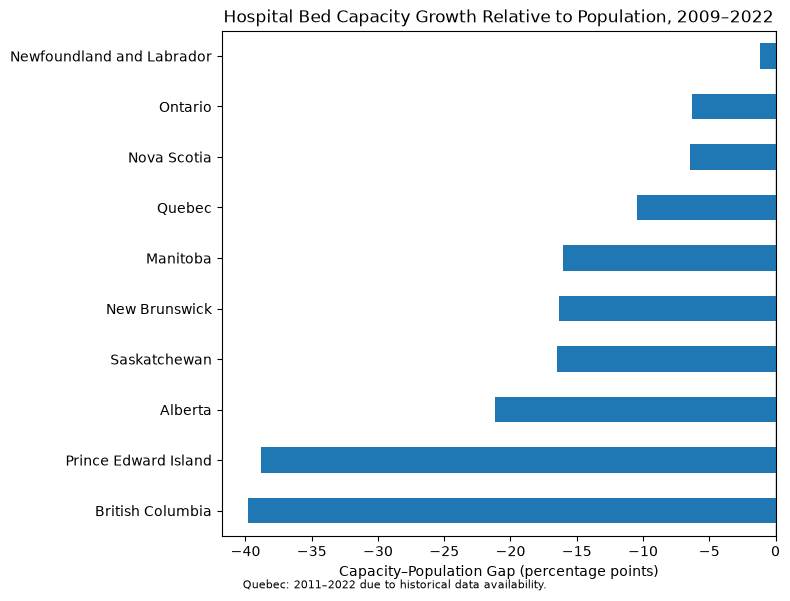

In [115]:
df_capacity_vs_population.sort_values("capacity_population_gap_pp")

ax = d.plot.barh(
    x="province_name",
    y="capacity_population_gap_pp",
    legend=False,
    figsize=(8, 6)
)

ax.axvline(0, linewidth=1)
ax.set_title("Hospital Bed Capacity Growth Relative to Population, 2009–2022")
ax.set_xlabel("Capacity–Population Gap (percentage points)")
ax.set_ylabel("")

plt.figtext(
    0.5, 0.01,
    "Quebec: 2011–2022 due to historical data availability.",
    ha="center", fontsize=8
)

plt.tight_layout()
plt.show()

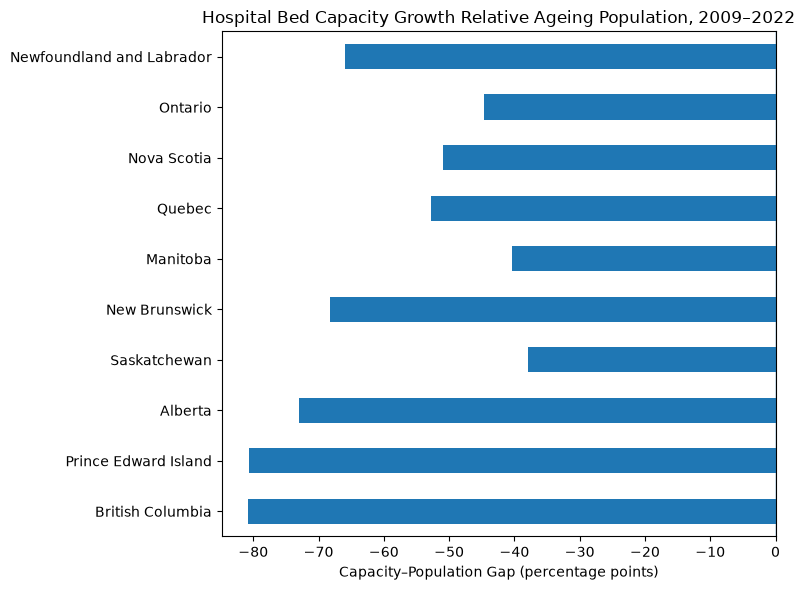

In [114]:
d = df_capacity_vs_population.sort_values("capacity_population_gap_pp")

ax = d.plot.barh(
    x="province_name",
    y="capacity_ageing_gap_pp",
    legend=False,
    figsize=(8, 6)
)

ax.axvline(0, linewidth=1)
ax.set_title("Hospital Bed Capacity Growth Relative Ageing Population, 2009–2022")
ax.set_xlabel("Capacity–Population Gap (percentage points)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [45]:
df_capacity_vs_population[
    [
        "province_code",
        "province_name",
        "bed_change_pct",
        "population_65_growth_pct",
        "capacity_ageing_gap_pp"
    ]
].sort_values("capacity_ageing_gap_pp", ascending=True)

,province_code,province_name,bed_change_pct,population_65_growth_pct,capacity_ageing_gap_pp
1,BC,British Columbia,-18.301639,62.486089,-80.787729
7,PE,Prince Edward Island,-19.295302,61.292282,-80.587584
0,AB,Alberta,1.485981,74.462869,-72.976888
3,NB,New Brunswick,-8.497669,59.788511,-68.286180
4,NL,Newfoundland and Labrador,1.675978,67.548559,-65.872581
8,QC,Quebec,0.095887,52.795665,-52.699779
5,NS,Nova Scotia,2.725832,53.687901,-50.962069
6,ON,Ontario,10.303818,55.010806,-44.706988
2,MB,Manitoba,0.893504,41.199158,-40.305654
9,SK,Saskatchewan,-2.560495,35.296645,-37.857141


> ##### **Insights:** 
> - ##### The result above indicates a substantial divergence between ageing population and hospital bed capacity between 2009-2022. In Alberta, for instance, the population aged 65+ increased by 74.5% between 2009 and 2022, compared with a 1.5% increase in staffed and operating hospital beds. British Columbia experienced a 62.5% increase in its 65+ population whle its staffed and operating beds declined by 18.3%. The 65+ population in Ontario increased by 55% compared with a 10% increase in beds. 
> - ##### Across all 10 provinces, the findings suggest that hospital bed capacity did not expand in proportion to the growth in older population which shows increasing demographic pressure reletaive to available hospital capacity. 

In [ ]:
d = df_capacity_vs_population.sort_values("capacity_population_gap_pp")

ax = d.plot.barh(
    x="province_name",
    y="capacity_population_gap_pp",
    legend=False,
    figsize=(8, 6)
)

ax.axvline(0, linewidth=1)
ax.set_title("Hospital Bed Capacity Growth Relative to Population, 2009–2022")
ax.set_xlabel("Capacity–Population Gap (percentage points)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

#### **2.5 - Workforce Analysis (2001-2024)**

In [46]:
df_healthcare_capacity["physicians_growth_pct"] = (
    df_healthcare_capacity
    .sort_values(["province_code", "data_year"])
    .groupby("province_code")["physicians_total"]
    .pct_change()
    * 100
)

In [47]:
df_healthcare_capacity[
    [
        "province_code",
        "province_name",
        "data_year",
        "physicians_total",
        "physicians_growth_pct"
    ]
]

,province_code,province_name,data_year,physicians_total,physicians_growth_pct
0,AB,Alberta,1971,NaN,NaN
1,AB,Alberta,1972,NaN,NaN
2,AB,Alberta,1973,NaN,NaN
3,AB,Alberta,1974,NaN,NaN
4,AB,Alberta,1975,NaN,NaN
...,...,...,...,...,...
545,SK,Saskatchewan,2021,2547.0,0.473373
546,SK,Saskatchewan,2022,2606.0,2.316451
547,SK,Saskatchewan,2023,2677.0,2.724482
548,SK,Saskatchewan,2024,2709.0,1.195368


In [48]:
df_healthcare_capacity[
    df_healthcare_capacity["physicians_total"].notna()
][
    [
    "province_name",
    "province_code",
    "data_year",
    "physicians_total",
    "physicians_growth_pct"
    ]
].head()

,province_name,province_code,data_year,physicians_total,physicians_growth_pct
30,Alberta,AB,2001,5154.0,NaN
31,Alberta,AB,2002,5637.0,9.371362
32,Alberta,AB,2003,5801.0,2.909349
33,Alberta,AB,2004,5953.0,2.620238
34,Alberta,AB,2005,6219.0,4.468335


In [49]:
df_physician_workforce_change = (
    df_healthcare_capacity[
        (df_healthcare_capacity["province_code"] != "CA") &
        (df_healthcare_capacity["physicians_total"].notna())
    ]
    .sort_values(["province_code", "data_year"])
    .groupby(["province_code", "province_name"])
    .agg(
        start_year=("data_year", "first"),
        end_year=("data_year", "last"),
        start_physicians=("physicians_total", "first"),
        end_physicians=("physicians_total", "last")
    )
    
    
).reset_index()

df_physician_workforce_change

,province_code,province_name,start_year,end_year,start_physicians,end_physicians
0,AB,Alberta,2001,2024,5154.0,11750.0
1,BC,British Columbia,2001,2024,8105.0,15460.0
2,MB,Manitoba,2001,2024,2093.0,3357.0
3,NB,New Brunswick,2001,2024,1179.0,2214.0
4,NL,Newfoundland and Labrador,2001,2024,945.0,1421.0
5,NS,Nova Scotia,2001,2024,1885.0,2888.0
6,ON,Ontario,2001,2024,21482.0,35653.0
7,PE,Prince Edward Island,2001,2024,190.0,377.0
8,QC,Quebec,2001,2024,15866.0,23562.0
9,SK,Saskatchewan,2001,2024,1549.0,2709.0


In [50]:
df_physician_workforce_change["physicians_growth_pct"] = (
    (df_physician_workforce_change["end_physicians"]
    - df_physician_workforce_change["start_physicians"])
    / df_physician_workforce_change["start_physicians"]
) * 100

df_physician_workforce_change

,province_code,province_name,start_year,end_year,start_physicians,end_physicians,physicians_growth_pct
0,AB,Alberta,2001,2024,5154.0,11750.0,127.978269
1,BC,British Columbia,2001,2024,8105.0,15460.0,90.746453
2,MB,Manitoba,2001,2024,2093.0,3357.0,60.391782
3,NB,New Brunswick,2001,2024,1179.0,2214.0,87.786260
4,NL,Newfoundland and Labrador,2001,2024,945.0,1421.0,50.370370
5,NS,Nova Scotia,2001,2024,1885.0,2888.0,53.209549
6,ON,Ontario,2001,2024,21482.0,35653.0,65.966856
7,PE,Prince Edward Island,2001,2024,190.0,377.0,98.421053
8,QC,Quebec,2001,2024,15866.0,23562.0,48.506240
9,SK,Saskatchewan,2001,2024,1549.0,2709.0,74.887024


#### **2.5.1 - Physician Growth vs Population Growth (2001-2024)**

In [51]:
df_population_physician = (
    df_healthcare_capacity[
       (df_healthcare_capacity["data_year"].isin([2001, 2024]))
    ]
    .sort_values(["province_code", "data_year"])
    .groupby(["province_code", "province_name"])
    .agg(
        start_population=("population", "first"),
        end_population=("population", "last")
    )
    .reset_index()
)

In [52]:
df_population_physician.head()

,province_code,province_name,start_population,end_population
0,AB,Alberta,3058554.0,4909030.0
1,BC,British Columbia,4076896.0,5671114.0
2,MB,Manitoba,1151451.0,1492144.0
3,NB,New Brunswick,749823.0,858293.0
4,NL,Newfoundland and Labrador,522043.0,546869.0


In [53]:
df_population_physician["population_growth_pct"] = (
    (df_population_physician["end_population"]
    -df_population_physician["start_population"])
    / df_population_physician["start_population"]
) * 100

In [54]:
df_population_physician

,province_code,province_name,start_population,end_population,population_growth_pct
0,AB,Alberta,3058554.0,4909030.0,60.501662
1,BC,British Columbia,4076896.0,5671114.0,39.103720
2,MB,Manitoba,1151451.0,1492144.0,29.588146
3,NB,New Brunswick,749823.0,858293.0,14.466081
4,NL,Newfoundland and Labrador,522043.0,546869.0,4.755547
5,NS,Nova Scotia,932483.0,1082769.0,16.116755
6,ON,Ontario,11897473.0,16144797.0,35.699379
7,PE,Prince Edward Island,136667.0,179709.0,31.494070
8,QC,Quebec,7396014.0,8995474.0,21.625973
9,SK,Saskatchewan,1000307.0,1247868.0,24.748502


In [55]:
df_physician_vs_population = df_physician_workforce_change[
    [
        "province_code",
        "province_name",
        "start_physicians",
        "end_physicians",
        "physicians_growth_pct"
    ]
].merge(
    df_population_physician[
        [
            "province_code",
            "province_name",
            "start_population",
            "end_population",
            "population_growth_pct"
        ]
    ],
    on=["province_code", "province_name"],
    how="inner"
)

In [56]:
df_physician_vs_population

,province_code,province_name,start_physicians,end_physicians,physicians_growth_pct,start_population,end_population,population_growth_pct
0,AB,Alberta,5154.0,11750.0,127.978269,3058554.0,4909030.0,60.501662
1,BC,British Columbia,8105.0,15460.0,90.746453,4076896.0,5671114.0,39.103720
2,MB,Manitoba,2093.0,3357.0,60.391782,1151451.0,1492144.0,29.588146
3,NB,New Brunswick,1179.0,2214.0,87.786260,749823.0,858293.0,14.466081
4,NL,Newfoundland and Labrador,945.0,1421.0,50.370370,522043.0,546869.0,4.755547
5,NS,Nova Scotia,1885.0,2888.0,53.209549,932483.0,1082769.0,16.116755
6,ON,Ontario,21482.0,35653.0,65.966856,11897473.0,16144797.0,35.699379
7,PE,Prince Edward Island,190.0,377.0,98.421053,136667.0,179709.0,31.494070
8,QC,Quebec,15866.0,23562.0,48.506240,7396014.0,8995474.0,21.625973
9,SK,Saskatchewan,1549.0,2709.0,74.887024,1000307.0,1247868.0,24.748502


In [57]:
df_physician_vs_population["physician_population_gap_pp"] = (
df_physician_vs_population["physicians_growth_pct"]
- df_physician_vs_population["population_growth_pct"])

In [58]:
df_physician_vs_population

,province_code,province_name,start_physicians,end_physicians,physicians_growth_pct,start_population,end_population,population_growth_pct,physician_population_gap_pp
0,AB,Alberta,5154.0,11750.0,127.978269,3058554.0,4909030.0,60.501662,67.476607
1,BC,British Columbia,8105.0,15460.0,90.746453,4076896.0,5671114.0,39.103720,51.642733
2,MB,Manitoba,2093.0,3357.0,60.391782,1151451.0,1492144.0,29.588146,30.803636
3,NB,New Brunswick,1179.0,2214.0,87.786260,749823.0,858293.0,14.466081,73.320179
4,NL,Newfoundland and Labrador,945.0,1421.0,50.370370,522043.0,546869.0,4.755547,45.614823
5,NS,Nova Scotia,1885.0,2888.0,53.209549,932483.0,1082769.0,16.116755,37.092794
6,ON,Ontario,21482.0,35653.0,65.966856,11897473.0,16144797.0,35.699379,30.267477
7,PE,Prince Edward Island,190.0,377.0,98.421053,136667.0,179709.0,31.494070,66.926983
8,QC,Quebec,15866.0,23562.0,48.506240,7396014.0,8995474.0,21.625973,26.880267
9,SK,Saskatchewan,1549.0,2709.0,74.887024,1000307.0,1247868.0,24.748502,50.138522


#### **2.5.2 - Physicians per 100k population (2001-2024)**

In [59]:
df_healthcare_capacity["physicians_per_100k"] = (
    df_healthcare_capacity["physicians_total"]
    /df_healthcare_capacity["population"]
) * 100000

In [60]:
df_healthcare_capacity["physicians_per_100k"] = (
    df_healthcare_capacity["physicians_total"]
    /df_healthcare_capacity["population"]
) * 100000

In [61]:
df_physician_per_100k_change = (
    df_healthcare_capacity[
       (df_healthcare_capacity["data_year"].isin([2001, 2024]))
    ]
    .sort_values(["province_code", "data_year"])
    .groupby(["province_code", "province_name"])
    .agg(
        start_physicians_per_100k=("physicians_per_100k", "first"),
        end_physicians_per_100k=("physicians_per_100k", "last")
    )
    .reset_index()
)

In [62]:
df_physician_per_100k_change["physicians_per_100k_change_pct"] =     (
       ( df_physician_per_100k_change["end_physicians_per_100k"]
        - df_physician_per_100k_change["start_physicians_per_100k"])
        /df_physician_per_100k_change["start_physicians_per_100k"]
    ) * 100

In [63]:
df_physician_per_100k_change.sort_values("physicians_per_100k_change_pct", ascending=False)

,province_code,province_name,start_physicians_per_100k,end_physicians_per_100k,physicians_per_100k_change_pct
3,NB,New Brunswick,157.237108,257.953869,64.054066
7,PE,Prince Edward Island,139.024051,209.783595,50.897340
4,NL,Newfoundland and Labrador,181.019571,259.842851,43.544065
0,AB,Alberta,168.511002,239.354822,42.041065
9,SK,Saskatchewan,154.852460,217.090269,40.191682
1,BC,British Columbia,198.803207,272.609579,37.125343
5,NS,Nova Scotia,202.148457,266.723558,31.944394
2,MB,Manitoba,181.770653,224.978286,23.770412
6,ON,Ontario,180.559351,220.832755,22.304801
8,QC,Quebec,214.520957,261.931723,22.100762


> ##### **Insights:** 
> - ##### The results above reveals that physician capacity increased substantially across all Canadian provinces and territories between 2001-2024. The results indicates that physician counts grew faster than population in every province, while physicians per 100,000 population increased across all provinces. The increase in physician density is obvious in New Brunswick, Prince Edward Island, Newfoundland and Lebrador, and Alberta, although the magnitude of changes in other jusrisdictions requires cautious interpretation because of their population characteristics. 
> - ##### The overall result suggests that physician workforce capacity expanded faster than population demand as measured by population growth during the period. Having said this, physician capacity alone cannot be interpreted as improved access or capacity since physician speciality, geographic characteristics, workload and population health needs are not captured.

#### **2.5.2 Registered Nurses Growth vs Population Growth (2015-2024)**

In [64]:
df_healthcare_capacity[
    [
        "province_code",
        "province_name",
        "data_year",
        "registered_nurses"
    ]
].dropna(subset=["registered_nurses"]).head()

,province_code,province_name,data_year,registered_nurses
44,AB,Alberta,2015,33773.0
45,AB,Alberta,2016,34651.0
46,AB,Alberta,2017,34356.0
47,AB,Alberta,2018,34079.0
48,AB,Alberta,2019,34372.0


In [65]:
df_healthcare_capacity["rn_growth_pct"] = (
    df_healthcare_capacity
    .sort_values(["province_code", "data_year"])
    .groupby("province_code")["registered_nurses"]
    .pct_change()
    * 100
)

In [66]:
df_healthcare_capacity["lpn_growth_pct"] = (
    df_healthcare_capacity
    .sort_values(["province_code", "data_year"])
    .groupby("province_code")["licensed_practical_nurses"]
    .pct_change(fill_method=None) 
    * 100
)

In [67]:
df_healthcare_capacity["np_growth_pct"] = (
    df_healthcare_capacity
    .sort_values(["province_code", "data_year"])
    .groupby("province_code")["nurse_practitioners"]
    .pct_change(fill_method=None)
    * 100
)

In [68]:
df_healthcare_capacity["rpn_growth_pct"] = (
    df_healthcare_capacity
    .sort_values(["province_code", "data_year"])
    .groupby("province_code")["registered_psychiatric_nurses"]
    .pct_change(fill_method=None)
    * 100
)

In [69]:
df_healthcare_capacity[
    [
        "province_code",
        "province_name",
        "data_year",
        "registered_nurses",
        "rn_growth_pct",
        "licensed_practical_nurses",
        "lpn_growth_pct",
        "nurse_practitioners",
        "np_growth_pct",
        "registered_psychiatric_nurses",
        "rpn_growth_pct"
    ]
].query("2015 <= data_year <= 2024").head()

,province_code,province_name,data_year,registered_nurses,rn_growth_pct,licensed_practical_nurses,lpn_growth_pct,nurse_practitioners,np_growth_pct,registered_psychiatric_nurses,rpn_growth_pct
44,AB,Alberta,2015,33773.0,NaN,10801.0,NaN,377.0,NaN,1284.0,NaN
45,AB,Alberta,2016,34651.0,2.599710,11631.0,7.684474,427.0,13.262599,1265.0,-1.479751
46,AB,Alberta,2017,34356.0,-0.851346,12272.0,5.511134,462.0,8.196721,1276.0,0.869565
47,AB,Alberta,2018,34079.0,-0.806264,12324.0,0.423729,504.0,9.090909,1295.0,1.489028
48,AB,Alberta,2019,34372.0,0.859767,13546.0,9.915612,549.0,8.928571,1308.0,1.003861


In [70]:
df_rn_change = (
    df_healthcare_capacity[
       (df_healthcare_capacity["registered_nurses"].notna())
    ]
    .sort_values(["province_code", "data_year"])
    .groupby(["province_code", "province_name"])
    .agg(
        start_year=("data_year", "first"),
        end_year=("data_year", "last"),
        start_rn=("registered_nurses", "first"),
        end_rn=("registered_nurses", "last")
    )
    .reset_index()
)

In [71]:
df_rn_change["rn_growth_pct"] = (
    (df_rn_change["end_rn"]
    - df_rn_change["start_rn"])
    / df_rn_change["start_rn"]
) * 100

In [72]:
df_rn_change

,province_code,province_name,start_year,end_year,start_rn,end_rn,rn_growth_pct
0,AB,Alberta,2015,2023,33773.0,34471.0,2.066740
1,BC,British Columbia,2015,2024,33545.0,41115.0,22.566701
2,MB,Manitoba,2015,2018,12165.0,11670.0,-4.069051
3,NB,New Brunswick,2015,2024,7855.0,7511.0,-4.379376
4,NL,Newfoundland and Labrador,2015,2024,5936.0,6208.0,4.582210
5,NS,Nova Scotia,2015,2024,9153.0,10801.0,18.005026
6,ON,Ontario,2015,2024,95659.0,106523.0,11.357008
7,PE,Prince Edward Island,2015,2024,1523.0,1803.0,18.384767
8,QC,Quebec,2015,2024,68435.0,77262.0,12.898371
9,SK,Saskatchewan,2015,2024,10054.0,11619.0,15.565944


In [73]:
df_rn_population = (
    df_healthcare_capacity[
      (df_healthcare_capacity["registered_nurses"].notna())
    ]
    .sort_values(["province_code", "data_year"])
    .groupby(["province_code", "province_name"])
    .agg(
        start_population=("population", "first"),
        end_population=("population", "last")
    ).reset_index()
)

df_rn_population

,province_code,province_name,start_population,end_population
0,AB,Alberta,4150147.0,4688576.0
1,BC,British Columbia,4765472.0,5671114.0
2,MB,Manitoba,1293598.0,1352687.0
3,NB,New Brunswick,759226.0,858293.0
4,NL,Newfoundland and Labrador,528348.0,546869.0
5,NS,Nova Scotia,937419.0,1082769.0
6,ON,Ontario,13709293.0,16144797.0
7,PE,Prince Edward Island,144636.0,179709.0
8,QC,Quebec,8175743.0,8995474.0
9,SK,Saskatchewan,1122210.0,1247868.0


In [74]:
df_rn_population["population_growth_pct"] = (
    (df_rn_population["end_population"]
     - df_rn_population["start_population"])
     / df_rn_population["start_population"]
) * 100

df_rn_population

,province_code,province_name,start_population,end_population,population_growth_pct
0,AB,Alberta,4150147.0,4688576.0,12.973733
1,BC,British Columbia,4765472.0,5671114.0,19.004246
2,MB,Manitoba,1293598.0,1352687.0,4.567802
3,NB,New Brunswick,759226.0,858293.0,13.048420
4,NL,Newfoundland and Labrador,528348.0,546869.0,3.505455
5,NS,Nova Scotia,937419.0,1082769.0,15.505340
6,ON,Ontario,13709293.0,16144797.0,17.765351
7,PE,Prince Edward Island,144636.0,179709.0,24.249150
8,QC,Quebec,8175743.0,8995474.0,10.026379
9,SK,Saskatchewan,1122210.0,1247868.0,11.197369


In [75]:
df_rn_vs_population = df_rn_population.merge(
    df_rn_change,
    on=["province_code", "province_name"],
    how="inner"
)
df_rn_vs_population

,province_code,province_name,start_population,end_population,population_growth_pct,start_year,end_year,start_rn,end_rn,rn_growth_pct
0,AB,Alberta,4150147.0,4688576.0,12.973733,2015,2023,33773.0,34471.0,2.066740
1,BC,British Columbia,4765472.0,5671114.0,19.004246,2015,2024,33545.0,41115.0,22.566701
2,MB,Manitoba,1293598.0,1352687.0,4.567802,2015,2018,12165.0,11670.0,-4.069051
3,NB,New Brunswick,759226.0,858293.0,13.048420,2015,2024,7855.0,7511.0,-4.379376
4,NL,Newfoundland and Labrador,528348.0,546869.0,3.505455,2015,2024,5936.0,6208.0,4.582210
5,NS,Nova Scotia,937419.0,1082769.0,15.505340,2015,2024,9153.0,10801.0,18.005026
6,ON,Ontario,13709293.0,16144797.0,17.765351,2015,2024,95659.0,106523.0,11.357008
7,PE,Prince Edward Island,144636.0,179709.0,24.249150,2015,2024,1523.0,1803.0,18.384767
8,QC,Quebec,8175743.0,8995474.0,10.026379,2015,2024,68435.0,77262.0,12.898371
9,SK,Saskatchewan,1122210.0,1247868.0,11.197369,2015,2024,10054.0,11619.0,15.565944


In [76]:
df_rn_vs_population["rn_population_gap_pp"] = (
    df_rn_vs_population["rn_growth_pct"]
    - df_rn_vs_population["population_growth_pct"]
)
df_rn_vs_population

,province_code,province_name,start_population,end_population,population_growth_pct,start_year,end_year,start_rn,end_rn,rn_growth_pct,rn_population_gap_pp
0,AB,Alberta,4150147.0,4688576.0,12.973733,2015,2023,33773.0,34471.0,2.066740,-10.906994
1,BC,British Columbia,4765472.0,5671114.0,19.004246,2015,2024,33545.0,41115.0,22.566701,3.562456
2,MB,Manitoba,1293598.0,1352687.0,4.567802,2015,2018,12165.0,11670.0,-4.069051,-8.636853
3,NB,New Brunswick,759226.0,858293.0,13.048420,2015,2024,7855.0,7511.0,-4.379376,-17.427797
4,NL,Newfoundland and Labrador,528348.0,546869.0,3.505455,2015,2024,5936.0,6208.0,4.582210,1.076756
5,NS,Nova Scotia,937419.0,1082769.0,15.505340,2015,2024,9153.0,10801.0,18.005026,2.499686
6,ON,Ontario,13709293.0,16144797.0,17.765351,2015,2024,95659.0,106523.0,11.357008,-6.408343
7,PE,Prince Edward Island,144636.0,179709.0,24.249150,2015,2024,1523.0,1803.0,18.384767,-5.864383
8,QC,Quebec,8175743.0,8995474.0,10.026379,2015,2024,68435.0,77262.0,12.898371,2.871991
9,SK,Saskatchewan,1122210.0,1247868.0,11.197369,2015,2024,10054.0,11619.0,15.565944,4.368574


In [77]:
df_rn_vs_population[
    [
        "province_code",
        "province_name",
        "rn_growth_pct",
        "population_growth_pct",
        "rn_population_gap_pp"
    ]
].sort_values("rn_population_gap_pp", ascending=False)

,province_code,province_name,rn_growth_pct,population_growth_pct,rn_population_gap_pp
9,SK,Saskatchewan,15.565944,11.197369,4.368574
1,BC,British Columbia,22.566701,19.004246,3.562456
8,QC,Quebec,12.898371,10.026379,2.871991
5,NS,Nova Scotia,18.005026,15.505340,2.499686
4,NL,Newfoundland and Labrador,4.582210,3.505455,1.076756
7,PE,Prince Edward Island,18.384767,24.249150,-5.864383
6,ON,Ontario,11.357008,17.765351,-6.408343
2,MB,Manitoba,-4.069051,4.567802,-8.636853
0,AB,Alberta,2.066740,12.973733,-10.906994
3,NB,New Brunswick,-4.379376,13.048420,-17.427797


> ##### **Insights:** 
> - ##### Registered Nurses workforce exceeded population growth in five of ten provinces. This suggests a relatively stronger nursing workforse in the five regions. However, population growth outpaced Registered Nurse growth in five provinces, most notably New Brunswick (-17.4 pp), Alberta (-10.9 pp), and Manitoba (-8.6 pp), indicating greater potential workforce pressure relative to population demand. Saskatchewan (+4.4 pp) and British Columbia (+3.6 pp) recorded the largest positive workforce-population gaps. 
> - ##### Overall, Registered capacity shows uneven alighnemt with population growth across jurisdictions.

#### **2.5.3 Licensed Practical Nurses Growth Vs Population Growth (2015-2024)**

In [78]:
df_lpn_change = (
    df_healthcare_capacity[
        (df_healthcare_capacity["licensed_practical_nurses"].notna())
    ]
    .sort_values(["province_code", "data_year"])
    .groupby(["province_code", "province_name"])
    .agg(
        start_year=("data_year", "first"),
        end_year=("data_year", "last"),
        start_lpn=("licensed_practical_nurses", "first"),
        end_lpn=("licensed_practical_nurses", "last")
    )
    .reset_index()
)

In [79]:
df_lpn_change["lpn_growth_pct"] = (
    (df_lpn_change["end_lpn"] - df_lpn_change["start_lpn"])
    / df_lpn_change["start_lpn"]
) * 100

In [80]:
df_lpn_change

,province_code,province_name,start_year,end_year,start_lpn,end_lpn,lpn_growth_pct
0,AB,Alberta,2015,2024,10801.0,16140.0,49.430608
1,BC,British Columbia,2015,2024,10483.0,13771.0,31.365067
2,MB,Manitoba,2015,2024,3032.0,3525.0,16.259894
3,NB,New Brunswick,2015,2024,3061.0,3496.0,14.211042
4,NL,Newfoundland and Labrador,2015,2024,2245.0,2448.0,9.042316
5,NS,Nova Scotia,2015,2024,3774.0,4314.0,14.308426
6,ON,Ontario,2015,2024,39069.0,53462.0,36.839950
7,PE,Prince Edward Island,2015,2024,548.0,755.0,37.773723
8,QC,Quebec,2015,2024,24867.0,26667.0,7.238509
9,SK,Saskatchewan,2015,2024,3230.0,3728.0,15.417957


In [81]:
df_lpn_population = (
    df_healthcare_capacity[
        (df_healthcare_capacity["province_code"] != "CA") &
        (df_healthcare_capacity["licensed_practical_nurses"].notna())
    ]
    .sort_values(["province_code", "data_year"])
    .groupby(["province_code", "province_name"])
    .agg(
        start_population=("population", "first"),
        end_population=("population", "last")
    ).reset_index()
)
df_lpn_population

,province_code,province_name,start_population,end_population
0,AB,Alberta,4150147.0,4909030.0
1,BC,British Columbia,4765472.0,5671114.0
2,MB,Manitoba,1293598.0,1492144.0
3,NB,New Brunswick,759226.0,858293.0
4,NL,Newfoundland and Labrador,528348.0,546869.0
5,NS,Nova Scotia,937419.0,1082769.0
6,ON,Ontario,13709293.0,16144797.0
7,PE,Prince Edward Island,144636.0,179709.0
8,QC,Quebec,8175743.0,8995474.0
9,SK,Saskatchewan,1122210.0,1247868.0


In [82]:
df_lpn_population["population_growth_pct"] = (
    (df_lpn_population["end_population"]
     - df_lpn_population["start_population"])
     / df_lpn_population["start_population"]
) * 100

In [83]:
df_lpn_vs_population = df_lpn_population.merge(
    df_lpn_change,
    on=["province_code", "province_name"],
    how="inner"
)

In [84]:
df_lpn_vs_population

,province_code,province_name,start_population,end_population,population_growth_pct,start_year,end_year,start_lpn,end_lpn,lpn_growth_pct
0,AB,Alberta,4150147.0,4909030.0,18.285690,2015,2024,10801.0,16140.0,49.430608
1,BC,British Columbia,4765472.0,5671114.0,19.004246,2015,2024,10483.0,13771.0,31.365067
2,MB,Manitoba,1293598.0,1492144.0,15.348354,2015,2024,3032.0,3525.0,16.259894
3,NB,New Brunswick,759226.0,858293.0,13.048420,2015,2024,3061.0,3496.0,14.211042
4,NL,Newfoundland and Labrador,528348.0,546869.0,3.505455,2015,2024,2245.0,2448.0,9.042316
5,NS,Nova Scotia,937419.0,1082769.0,15.505340,2015,2024,3774.0,4314.0,14.308426
6,ON,Ontario,13709293.0,16144797.0,17.765351,2015,2024,39069.0,53462.0,36.839950
7,PE,Prince Edward Island,144636.0,179709.0,24.249150,2015,2024,548.0,755.0,37.773723
8,QC,Quebec,8175743.0,8995474.0,10.026379,2015,2024,24867.0,26667.0,7.238509
9,SK,Saskatchewan,1122210.0,1247868.0,11.197369,2015,2024,3230.0,3728.0,15.417957


In [85]:
df_lpn_vs_population["lpn_population_gap_pp"]= (
    df_lpn_vs_population["lpn_growth_pct"] - df_lpn_vs_population["population_growth_pct"]
)

In [86]:
df_lpn_vs_population[
    [
        "province_code",
        "province_name",
        "lpn_growth_pct",
        "population_growth_pct",
        "lpn_population_gap_pp"
    ]
].sort_values("lpn_population_gap_pp", ascending=False)

,province_code,province_name,lpn_growth_pct,population_growth_pct,lpn_population_gap_pp
0,AB,Alberta,49.430608,18.285690,31.144919
6,ON,Ontario,36.839950,17.765351,19.074599
7,PE,Prince Edward Island,37.773723,24.249150,13.524573
1,BC,British Columbia,31.365067,19.004246,12.360822
4,NL,Newfoundland and Labrador,9.042316,3.505455,5.536862
9,SK,Saskatchewan,15.417957,11.197369,4.220587
3,NB,New Brunswick,14.211042,13.048420,1.162622
2,MB,Manitoba,16.259894,15.348354,0.911540
5,NS,Nova Scotia,14.308426,15.505340,-1.196914
8,QC,Quebec,7.238509,10.026379,-2.787870


> ##### **Insights:**
> - ##### The result above indicates that Licensed Practical Nurses workforce exceeded population in growth in eight our of ten provinces. It suggests a relatively strong workforce expansion in most areas. Alberta recorded the largest positive gaps (+31.1 pp) and Ontario (+19.1 pp). Population growth slightly exceeded LPN growth in Nova Scotia (-1.2 pp) and Quebec (-2.8 pp). 
> - ##### Above all, LPN workforce capacity expanded faster than population growth across most provinces, suggesting general stronger workfore-poulation alighment than observed Registered Nurses.

#### **2.5.4 Nurse Practioners (NPs) Growth vs Population Growth (2015-2024)**

In [87]:
df_np_change = (
    df_healthcare_capacity[
        (df_healthcare_capacity["nurse_practitioners"].notna())
    ]
    .sort_values(["province_code", "data_year"])
    .groupby(["province_code", "province_name"])
    .agg(
        start_year=("data_year", "first"),
        end_year=("data_year", "last"),
        start_np=("nurse_practitioners", "first"),
        end_np=("nurse_practitioners", "last"),
        start_population=("population", "first"),
        end_population=("population", "last")
    ).reset_index()
)
df_np_change

,province_code,province_name,start_year,end_year,start_np,end_np,start_population,end_population
0,AB,Alberta,2015,2023,377.0,680.0,4150147.0,4688576.0
1,BC,British Columbia,2015,2024,236.0,961.0,4765472.0,5671114.0
2,MB,Manitoba,2015,2018,148.0,174.0,1293598.0,1352687.0
3,NB,New Brunswick,2015,2024,106.0,219.0,759226.0,858293.0
4,NL,Newfoundland and Labrador,2015,2024,136.0,290.0,528348.0,546869.0
5,NS,Nova Scotia,2015,2024,143.0,360.0,937419.0,1082769.0
6,ON,Ontario,2015,2024,2405.0,4493.0,13709293.0,16144797.0
7,PE,Prince Edward Island,2015,2024,14.0,76.0,144636.0,179709.0
8,QC,Quebec,2015,2024,303.0,1655.0,8175743.0,8995474.0
9,SK,Saskatchewan,2015,2024,172.0,267.0,1122210.0,1247868.0


In [88]:
df_np_change["np_growth_pct"] = (
    (df_np_change["end_np"] - df_np_change["start_np"])
    / df_np_change["start_np"]
) * 100

df_np_change

,province_code,province_name,start_year,end_year,start_np,end_np,start_population,end_population,np_growth_pct
0,AB,Alberta,2015,2023,377.0,680.0,4150147.0,4688576.0,80.371353
1,BC,British Columbia,2015,2024,236.0,961.0,4765472.0,5671114.0,307.203390
2,MB,Manitoba,2015,2018,148.0,174.0,1293598.0,1352687.0,17.567568
3,NB,New Brunswick,2015,2024,106.0,219.0,759226.0,858293.0,106.603774
4,NL,Newfoundland and Labrador,2015,2024,136.0,290.0,528348.0,546869.0,113.235294
5,NS,Nova Scotia,2015,2024,143.0,360.0,937419.0,1082769.0,151.748252
6,ON,Ontario,2015,2024,2405.0,4493.0,13709293.0,16144797.0,86.819127
7,PE,Prince Edward Island,2015,2024,14.0,76.0,144636.0,179709.0,442.857143
8,QC,Quebec,2015,2024,303.0,1655.0,8175743.0,8995474.0,446.204620
9,SK,Saskatchewan,2015,2024,172.0,267.0,1122210.0,1247868.0,55.232558


In [89]:
df_np_change["population_growth_pct"] = (
    (df_np_change["end_population"] - df_np_change["start_population"])
    / df_np_change["start_population"]
) * 100

In [90]:
df_np_vs_population = df_np_change

In [91]:
df_np_vs_population["np_population_gap_pp"] = (
    df_np_vs_population["np_growth_pct"] - df_np_vs_population["population_growth_pct"]
)

In [92]:
df_np_vs_population[
    [
        "province_code",
        "province_name",
        "np_growth_pct",
        "population_growth_pct",
        "np_population_gap_pp"
    ]
].sort_values("np_population_gap_pp", ascending=False)

,province_code,province_name,np_growth_pct,population_growth_pct,np_population_gap_pp
8,QC,Quebec,446.204620,10.026379,436.178241
7,PE,Prince Edward Island,442.857143,24.249150,418.607993
1,BC,British Columbia,307.203390,19.004246,288.199144
5,NS,Nova Scotia,151.748252,15.505340,136.242912
4,NL,Newfoundland and Labrador,113.235294,3.505455,109.729839
3,NB,New Brunswick,106.603774,13.048420,93.555353
6,ON,Ontario,86.819127,17.765351,69.053776
0,AB,Alberta,80.371353,12.973733,67.397620
9,SK,Saskatchewan,55.232558,11.197369,44.035189
2,MB,Manitoba,17.567568,4.567802,12.999765


> ##### **Insights:**
> - ##### The result above shows that Nurse Practitioner (NP) workforce recorded faster growth than population growth in all 10 provinces based on the available data. The largest workforce-population gaps were observed in Quebec (+436.2 pp), Prince Edward Island (418.6 pp), and British Columbia (+288.2 pp). Alberta  and Ontario also recorded substantial growth of (+67.4 pp) and (+69.1 pp) respectively. 
> - ##### Overall, the data indicates NP workorce increased faster than poulatin growth across all provinces, although some of the large percentage points recorded in some provinces partly reflect their small starting workforce bases. These results are descriptive workforce expansion relative to population and do not by themselves establish improvements in healthcare access or outcomes.

#### **2.5.4 Registered Psychiatric Nurses (RPNs) Growth vs Population Growth (2015-2024)**

In [93]:
df_rpn_change = (
    df_healthcare_capacity[
        (df_healthcare_capacity["province_code"] != "CA") &
        (df_healthcare_capacity["registered_psychiatric_nurses"].notna())
    ]
    .sort_values(["province_code", "data_year"])
    .groupby(["province_code", "province_name"])
    .agg(
        start_year=("data_year", "first"),
        end_year=("data_year", "last"),
        start_rpn=("registered_psychiatric_nurses", "first"),
        end_rpn=("registered_psychiatric_nurses", "last"),
        start_population=("population", "first"),
        end_population=("population", "last")
    ).reset_index()
)

df_rpn_change

,province_code,province_name,start_year,end_year,start_rpn,end_rpn,start_population,end_population
0,AB,Alberta,2015,2024,1284.0,1439.0,4150147.0,4909030.0
1,BC,British Columbia,2015,2024,2400.0,3332.0,4765472.0,5671114.0
2,MB,Manitoba,2015,2024,938.0,1088.0,1293598.0,1492144.0
3,SK,Saskatchewan,2015,2024,841.0,702.0,1122210.0,1247868.0


In [94]:
df_rpn_change["rpn_growth_pct"] = (
    (df_rpn_change["end_rpn"] - df_rpn_change["start_rpn"])
    / df_rpn_change["start_rpn"]
) * 100

In [95]:
df_rpn_change["population_growth_pct"] = (
    (df_rpn_change["end_population"] - df_rpn_change["start_population"])
    / df_rpn_change["start_population"]
) * 100

In [96]:
df_rpn_change

,province_code,province_name,start_year,end_year,start_rpn,end_rpn,start_population,end_population,rpn_growth_pct,population_growth_pct
0,AB,Alberta,2015,2024,1284.0,1439.0,4150147.0,4909030.0,12.071651,18.285690
1,BC,British Columbia,2015,2024,2400.0,3332.0,4765472.0,5671114.0,38.833333,19.004246
2,MB,Manitoba,2015,2024,938.0,1088.0,1293598.0,1492144.0,15.991471,15.348354
3,SK,Saskatchewan,2015,2024,841.0,702.0,1122210.0,1247868.0,-16.527943,11.197369


In [97]:
df_rpn_vs_population = df_rpn_change

In [98]:
df_rpn_vs_population

,province_code,province_name,start_year,end_year,start_rpn,end_rpn,start_population,end_population,rpn_growth_pct,population_growth_pct
0,AB,Alberta,2015,2024,1284.0,1439.0,4150147.0,4909030.0,12.071651,18.285690
1,BC,British Columbia,2015,2024,2400.0,3332.0,4765472.0,5671114.0,38.833333,19.004246
2,MB,Manitoba,2015,2024,938.0,1088.0,1293598.0,1492144.0,15.991471,15.348354
3,SK,Saskatchewan,2015,2024,841.0,702.0,1122210.0,1247868.0,-16.527943,11.197369


In [99]:
df_rpn_vs_population["rpn_population_gap_pp"] = (
    df_rpn_vs_population["rpn_growth_pct"] - df_rpn_vs_population["population_growth_pct"]
)

In [100]:
df_rpn_vs_population[
    [
        "province_code",
        "province_name",
        "rpn_growth_pct",
        "population_growth_pct",
        "rpn_population_gap_pp"
    ]
].sort_values("rpn_population_gap_pp", ascending=False)

,province_code,province_name,rpn_growth_pct,population_growth_pct,rpn_population_gap_pp
1,BC,British Columbia,38.833333,19.004246,19.829088
2,MB,Manitoba,15.991471,15.348354,0.643117
0,AB,Alberta,12.071651,18.285690,-6.214039
3,SK,Saskatchewan,-16.527943,11.197369,-27.725312


> ##### **Insight:** 
> - ##### British Columbia (+19.8 pp) and Manitoba (+0.6 pp) workforce growth exceeded population showing a relatively stronger workforece expansion in these jurisdictions. In contrast, population growth exceeded RPN workforce growth in Alberta (-6.2 pp) and Saskatchewan (-22.7 pp), with the largest gap being in Saskatchewan. RPN workforce capacity shows an uneven alignment with population growth across the four jurisdictions with available data, ranging from modest workforce expansion above population growth in Manitoba to a substantial workforce-population gap in Saskatchewan. These are descriptive results and do not establish any effects on healthcare access or outcomes.

> ##### **Section Conclusion** 
> - ##### Hospital beds capacity generally expanded more slowly than population and the 65+ ageing population and a declining beds per 100,000 in most provinces. Physician, LPN, and NP workforces generally grew faster than population, while RN nad RPN growth showed more mixed alignment. In conclusion, helath capacity shows mixed alignment with population and demographic demand, with greater relatice pressure in hospital infrastructure and selected nursing categories.

<table width="100%">
<tr>
<td width="50%" align="left"><a href="./01_RQ1_population_demand.ipynb">← Previous: RQ1 — Population Demand</a></td>
<td width="50%" align="right"><a href="./03_RQ3_expenditure_resources.ipynb">Next: RQ3 — Expenditure Resources →</a></td>
</tr>
</table>

In [101]:
df_healthcare_capacity

,province_id,province_code,province_name,data_year,population,population_65_plus,population_80_plus,population_85_plus,population_65_share_pct,population_80_share_pct,...,rehabilitation_beds,bed_change,bed_growth_pct,beds_per_100k,physicians_growth_pct,physicians_per_100k,rn_growth_pct,lpn_growth_pct,np_growth_pct,rpn_growth_pct
0,6,AB,Alberta,1971,1665717.0,120453.0,25438.0,10431.0,7.231300,1.527150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6,AB,Alberta,1972,1694090.0,123588.0,26188.0,10894.0,7.295244,1.545845,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6,AB,Alberta,1973,1725327.0,126985.0,26669.0,11424.0,7.360054,1.545736,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6,AB,Alberta,1974,1754621.0,130045.0,27048.0,11973.0,7.411572,1.541529,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6,AB,Alberta,1975,1808689.0,134156.0,27442.0,12282.0,7.417306,1.517232,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,17,SK,Saskatchewan,2021,1167711.0,198565.0,50771.0,27399.0,17.004636,4.347908,...,80.0,667.0,19.106273,356.081256,0.473373,218.119038,0.836976,-2.972750,6.194690,0.991501
546,17,SK,Saskatchewan,2022,1178796.0,204647.0,50862.0,26970.0,17.360680,4.314741,...,73.0,-695.0,-16.714767,293.774326,2.316451,221.073027,2.739094,0.453901,9.583333,-4.768583
547,17,SK,Saskatchewan,2023,1210257.0,211510.0,51537.0,26972.0,17.476453,4.258352,...,NaN,NaN,NaN,NaN,2.724482,221.192689,0.359066,3.275911,-3.422053,1.914580
548,17,SK,Saskatchewan,2024,1247868.0,218531.0,52274.0,27014.0,17.512349,4.189065,...,NaN,NaN,NaN,NaN,1.195368,217.090269,3.926655,1.941482,5.118110,1.445087


In [104]:
beds_plot = (
    df_healthcare_capacity[
        [
            "province_code",
            "province_name",
            "data_year",
            "beds_per_100k"
        ]
    ]
    .query("2009 <= data_year <= 2022")
    .dropna(subset=["beds_per_100k"])
    .sort_values(["province_code", "data_year"])
)

In [105]:
beds_plot["province_name"].unique()

<StringArray>
[                  'Alberta',          'British Columbia',
                  'Manitoba',             'New Brunswick',
 'Newfoundland and Labrador',               'Nova Scotia',
                   'Ontario',      'Prince Edward Island',
                    'Quebec',              'Saskatchewan']
Length: 10, dtype: str

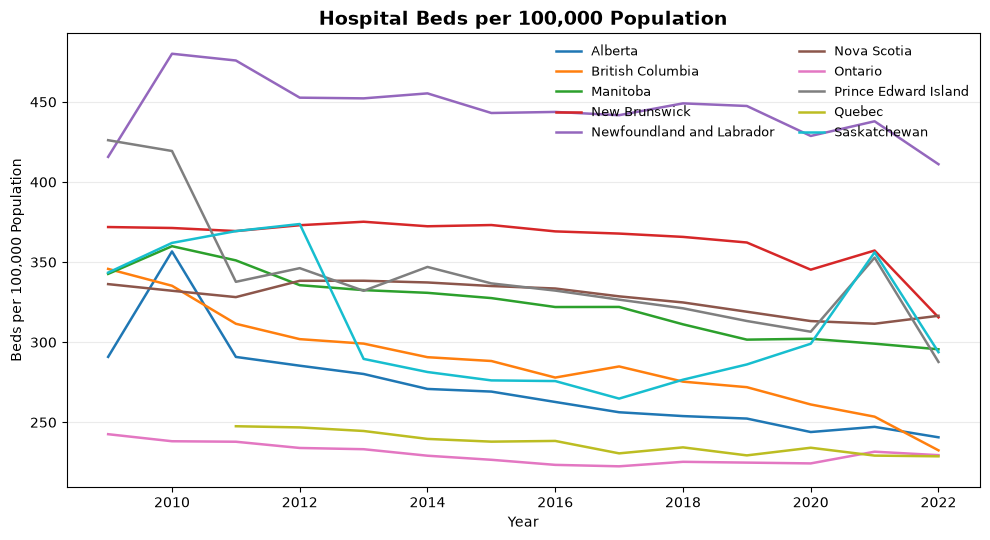

In [106]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5.5))

for province, group in beds_plot.groupby("province_name"):
    ax.plot(
        group["data_year"],
        group["beds_per_100k"],
        linewidth=1.8,
        label=province
    )

ax.set_title(
    "Hospital Beds per 100,000 Population",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Year")
ax.set_ylabel("Beds per 100,000 Population")

ax.legend(
    frameon=False,
    ncol=2,
    fontsize=9
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [107]:
d = df_capacity.sort_values("capacity_population_gap_pp")

ax = d.plot.barh(
    x="province_name",
    y="capacity_population_gap_pp",
    legend=False,
    figsize=(8, 6)
)

ax.axvline(0, linewidth=1)
ax.set_title("Hospital Capacity Growth Relative to Population, 2009–2022")
ax.set_xlabel("Capacity–Population Gap (percentage points)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

NameError: name 'df_capacity' is not defined

In [102]:
df_healthcare_capacity.columns.tolist()

['province_id',
 'province_code',
 'province_name',
 'data_year',
 'population',
 'population_65_plus',
 'population_80_plus',
 'population_85_plus',
 'population_65_share_pct',
 'population_80_share_pct',
 'population_85_share_pct',
 'hospital_beds_total',
 'current_hospital_beds_total',
 'physicians_total',
 'registered_nurses',
 'licensed_practical_nurses',
 'nurse_practitioners',
 'registered_psychiatric_nurses',
 'icu_beds',
 'long_term_care_beds',
 'mental_health_addictions_beds',
 'obstetrics_beds',
 'other_acute_care_beds',
 'pediatrics_beds',
 'rated_capacity_beds',
 'rehabilitation_beds',
 'bed_change',
 'bed_growth_pct',
 'beds_per_100k',
 'physicians_growth_pct',
 'physicians_per_100k',
 'rn_growth_pct',
 'lpn_growth_pct',
 'np_growth_pct',
 'rpn_growth_pct']